### Step 14 — Baseline Modeling

In this step, we train our first machine learning models to predict churn.

Objectives:
- Validate whether our features are meaningful
- Establish baseline performance
- Detect overfitting or underfitting
- Understand model behavior

We start with simple models:
- Logistic Regression
- Decision Tree

These models help us evaluate the quality of the dataset before using advanced models.

1. Import Libraries

We import machine learning models and evaluation metrics.

In [231]:
!pip install scikit-learn

In [232]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

2. Load Saved Train/Test Data

We load previously saved datasets for modeling.

In [233]:
import pandas as pd

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [234]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(68526, 38)
(36463, 38)
(68526,)
(36463,)


In [235]:
X_train.isnull().sum().sum()
X_test.isnull().sum().sum()

np.int64(0)

In [236]:
X_train.columns.equals(X_test.columns)

True

In [237]:
X_train.dtypes

cc_call_ratio                float64
low_engagement               float64
Total_Renewal_Score_New      float64
negative_calls               float64
cc_financial_stress_calls    float64
cc_pricing_issue_calls       float64
cc_platform_issue_calls      float64
email_financial_issue        float64
low_payment_intent_count     float64
tenure_bucket_TB_1-3         float64
tenure_bucket_TB_10+         float64
tenure_bucket_TB_3-5         float64
tenure_bucket_TB_5-10        float64
tenure_bucket_TB_Unknown     float64
Band_band a                  float64
Band_band b                  float64
Band_band c1                 float64
Band_band c2                 float64
Band_band d                  float64
Band_band e                  float64
Band_band f                  float64
Band_band f1                 float64
Band_band f2                 float64
Band_band g                  float64
Band_band h                  float64
Band_band i                  float64
Band_band j                  float64
B

In [238]:
y_train.dtypes

dtype('int64')

##### Logistic Regression

This model serves as the baseline.
It predicts the probability of churn.

In [239]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predictions (Logistic Regression)

In [240]:
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

y_test_prob_lr = lr_model.predict_proba(X_test)[:, 1]

Evaluation (Logistic Regression)

Metrics:
- Accuracy → overall correctness
- Recall → ability to detect churn (important)
- AUC → model discrimination ability

In [241]:
print("=== Logistic Regression ===")

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_lr))

print("AUC Score:", roc_auc_score(y_test, y_test_prob_lr))

=== Logistic Regression ===
Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     32726
           1       0.90      0.03      0.05      3737

    accuracy                           0.90     36463
   macro avg       0.90      0.51      0.50     36463
weighted avg       0.90      0.90      0.86     36463

AUC Score: 0.970622781600428


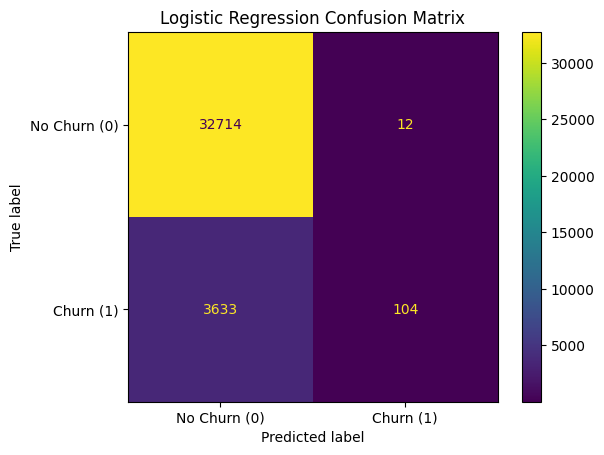

In [242]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_lr,
    display_labels=["No Churn (0)", "Churn (1)"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

##### Decision Tree

Captures non-linear relationships between features.
Depth is limited to avoid overfitting.

In [243]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [244]:
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

y_test_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [245]:
print("\n=== Decision Tree ===")

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_dt))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_dt))

print("AUC Score:", roc_auc_score(y_test, y_test_prob_dt))


=== Decision Tree ===
Train Accuracy: 0.950704841957797
Test Accuracy: 0.9068644927734965

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     32726
           1       0.81      0.12      0.21      3737

    accuracy                           0.91     36463
   macro avg       0.86      0.56      0.58     36463
weighted avg       0.90      0.91      0.87     36463

AUC Score: 0.6769858297985932


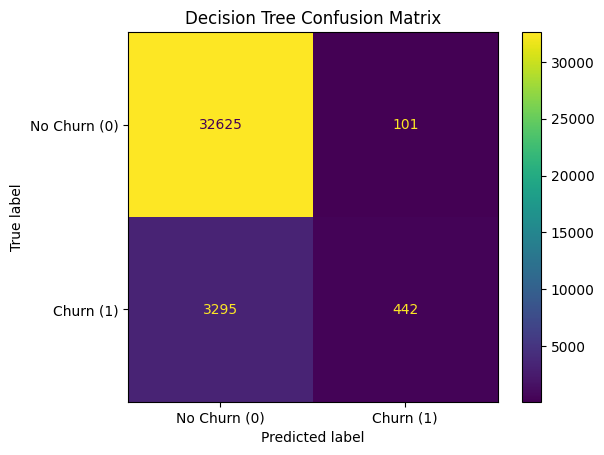

In [246]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_dt,
    display_labels=["No Churn (0)", "Churn (1)"]
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [247]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_shuffled = y_train.sample(frac=1.0, random_state=42).values

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_shuffled)

pred = lr.predict(X_test)
print("Accuracy with shuffled labels:", accuracy_score(y_test, pred))

Accuracy with shuffled labels: 0.897512546965417


In [248]:
for col in X_train.columns:
    tmp_tr = X_train.drop(columns=[col])
    tmp_te = X_test.drop(columns=[col])

    lr = LogisticRegression(max_iter=1000)
    lr.fit(tmp_tr, y_train)
    acc = lr.score(tmp_te, y_test)
    print(col, acc)

cc_call_ratio 0.8999808024572855
low_engagement 0.9008309793489291
Total_Renewal_Score_New 0.8959767435482544
negative_calls 0.90014535282341
cc_financial_stress_calls 0.9000082275183062
cc_pricing_issue_calls 0.9000082275183062
cc_platform_issue_calls 0.9000630776403478
email_financial_issue 0.9002002029454516
low_payment_intent_count 0.9015714559964896
tenure_bucket_TB_1-3 0.8998711022132024
tenure_bucket_TB_10+ 0.90014535282341
tenure_bucket_TB_3-5 0.8999808024572855
tenure_bucket_TB_5-10 0.8999808024572855
tenure_bucket_TB_Unknown 0.8999808024572855
Band_band a 0.9000082275183062
Band_band b 0.9000905027013685
Band_band c1 0.8999533773962647
Band_band c2 0.8999808024572855
Band_band d 0.9000356525793269
Band_band e 0.9000082275183062
Band_band f 0.9000630776403478
Band_band f1 0.8999533773962647
Band_band f2 0.8999808024572855
Band_band g 0.8999808024572855
Band_band h 0.8999808024572855
Band_band i 0.9000082275183062
Band_band j 0.8998985272742231
Band_group 0.9000356525793269
Anc

In [249]:
import pandas as pd

for col in X_train.columns[:10]:  # sample
    print(col)
    print("Train mean:", X_train[col].mean(), "Test mean:", X_test[col].mean())

cc_call_ratio
Train mean: 0.00013668777787506447 Test mean: 0.058526296370138065
low_engagement
Train mean: 0.17448851530805826 Test mean: 0.015851685269999725
Total_Renewal_Score_New
Train mean: 41.42313136619677 Test mean: 42.46962674491951
negative_calls
Train mean: 0.1270320754166302 Test mean: 0.12459205221731619
cc_financial_stress_calls
Train mean: 0.021524676765023495 Test mean: 0.0248196802237885
cc_pricing_issue_calls
Train mean: 0.09052038642267168 Test mean: 0.10218577736335463
cc_platform_issue_calls
Train mean: 0.05113387619297785 Test mean: 0.056687601129912515
email_financial_issue
Train mean: 0.1352041560867408 Test mean: 0.16860927515563723
low_payment_intent_count
Train mean: 2.0499810290984444 Test mean: 2.486164056715026
tenure_bucket_TB_1-3
Train mean: 0.2062720719143099 Test mean: 0.20670268491347393


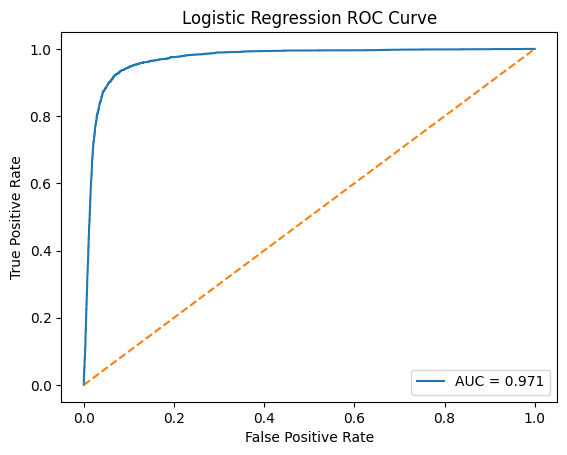

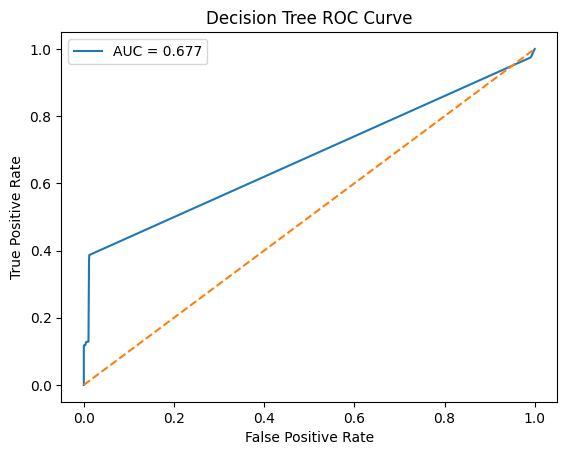

In [250]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_test, y_prob, title):
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_roc_curve(y_test, y_test_prob_lr, "Logistic Regression ROC Curve")
plot_roc_curve(y_test, y_test_prob_dt, "Decision Tree ROC Curve")


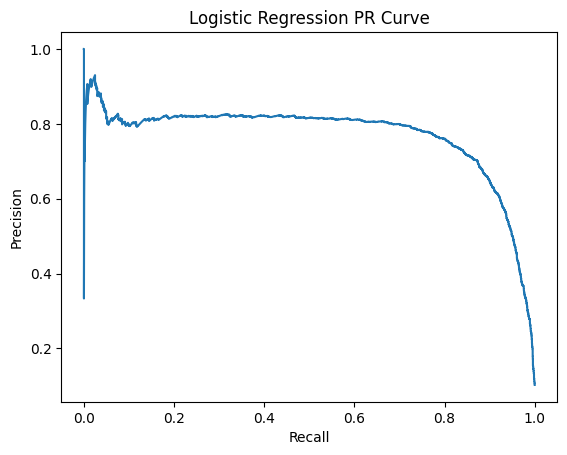

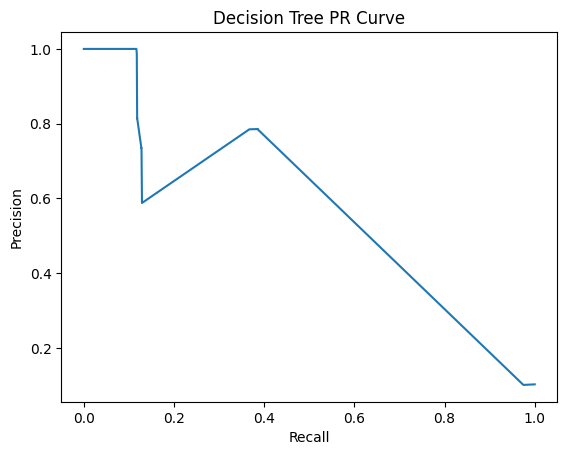

In [251]:
from sklearn.metrics import precision_recall_curve

def plot_pr_curve(y_test, y_prob, title):
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure()
    plt.plot(recall, precision)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.show()

plot_pr_curve(y_test, y_test_prob_lr, "Logistic Regression PR Curve")
plot_pr_curve(y_test, y_test_prob_dt, "Decision Tree PR Curve")

### Step 15 — Handling Class Imbalance

The dataset is imbalanced:
- Non-churn ≈ 90%
- Churn ≈ 10%

To improve churn detection:
- We use class weighting to give more importance to churn
- We adjust prediction threshold to improve recall

SMOTE is not used to avoid synthetic data distortion.

##### Logistic Regression with Class Weight

In [252]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Predictions

In [253]:
y_prob = lr_model.predict_proba(X_test)[:, 1]

Threshold Comparison

In [254]:
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (y_prob > t).astype(int)

    print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))

Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     32726
           1       0.68      0.18      0.28      3737

    accuracy                           0.91     36463
   macro avg       0.80      0.58      0.61     36463
weighted avg       0.89      0.91      0.88     36463

Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     32726
           1       0.74      0.33      0.46      3737

    accuracy                           0.92     36463
   macro avg       0.84      0.66      0.71     36463
weighted avg       0.91      0.92      0.91     36463

Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.98   

Threshold Tuning

We reduce the threshold to improve churn recall.

In [255]:
threshold = 0.1 

y_pred = (y_prob > threshold).astype(int)

Evaluation

In [256]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
print("=== Logistic Regression ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("AUC Score:", roc_auc_score(y_test, y_prob))



=== Logistic Regression ===
Train Accuracy: 0.9518139100487406
Test Accuracy: 0.9000356525793269

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     32726
           1       0.71      0.94      0.81      3737

    accuracy                           0.96     36463
   macro avg       0.85      0.95      0.89     36463
weighted avg       0.96      0.96      0.96     36463

AUC Score: 0.9776821089945726


Confusion Matrix

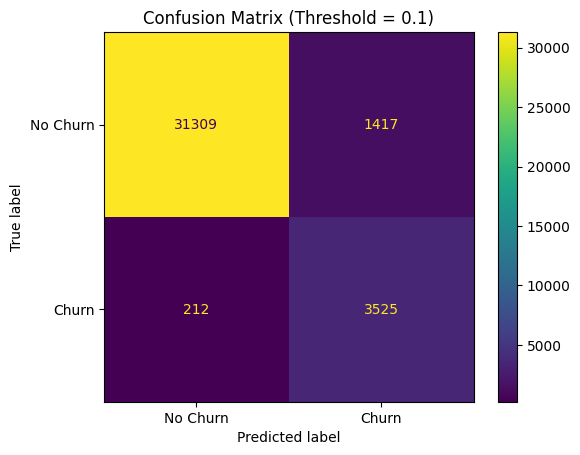

In [257]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.show()

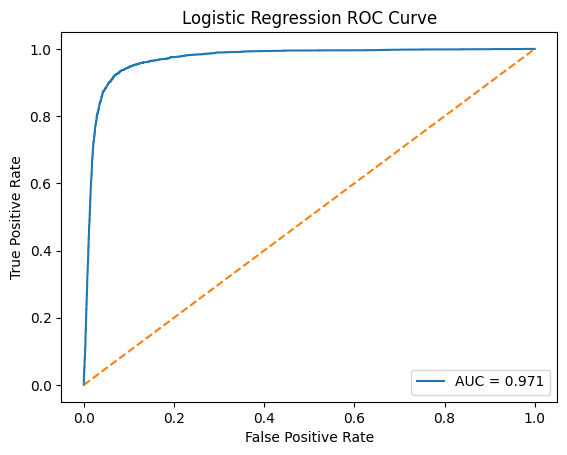

In [258]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_test, y_prob, title):
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_roc_curve(y_test, y_test_prob_lr, "Logistic Regression ROC Curve")



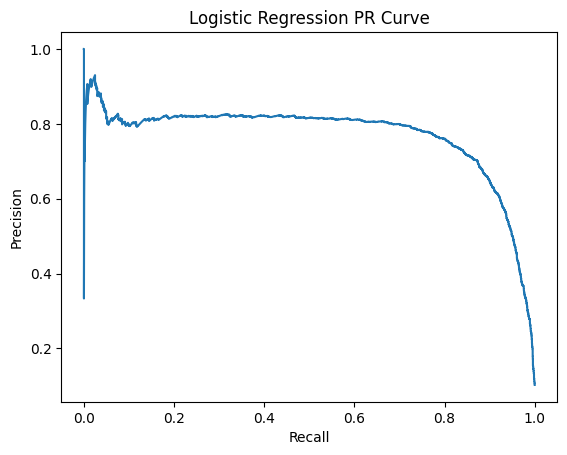

In [259]:
from sklearn.metrics import precision_recall_curve

def plot_pr_curve(y_test, y_prob, title):
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure()
    plt.plot(recall, precision)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.show()

plot_pr_curve(y_test, y_test_prob_lr, "Logistic Regression PR Curve")


##### Decision Tree with Class Weight

In [260]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [261]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [262]:
from sklearn.metrics import classification_report, accuracy_score

for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    
    y_pred_dt = (y_prob_dt > t).astype(int)

    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred_dt))
    print(classification_report(y_test, y_pred_dt))


Threshold: 0.5
Accuracy: 0.8932890875682198
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     32726
           1       0.17      0.01      0.02      3737

    accuracy                           0.89     36463
   macro avg       0.54      0.50      0.48     36463
weighted avg       0.82      0.89      0.85     36463


Threshold: 0.4
Accuracy: 0.8932890875682198
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     32726
           1       0.17      0.01      0.02      3737

    accuracy                           0.89     36463
   macro avg       0.54      0.50      0.48     36463
weighted avg       0.82      0.89      0.85     36463


Threshold: 0.3
Accuracy: 0.8938375887886351
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     32726
           1       0.24      0.02      0.03      3737

    accuracy                           0.89    

In [263]:
for depth in [3, 5, 7, 10]:
    
    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )

    dt_model.fit(X_train, y_train)

    y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
    y_pred_dt = (y_prob_dt > 0.2).astype(int)

    print(f"\nDepth: {depth}")
    print(classification_report(y_test, y_pred_dt))


Depth: 3
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     32726
           1       0.16      0.02      0.03      3737

    accuracy                           0.89     36463
   macro avg       0.53      0.50      0.49     36463
weighted avg       0.82      0.89      0.85     36463


Depth: 5
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     32726
           1       0.24      0.02      0.03      3737

    accuracy                           0.89     36463
   macro avg       0.57      0.51      0.49     36463
weighted avg       0.83      0.89      0.85     36463


Depth: 7
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     32726
           1       0.86      0.37      0.52      3737

    accuracy                           0.93     36463
   macro avg       0.90      0.68      0.74     36463
weighted avg       0.93      0.93      0.92 

### Step 16 — Advanced Modeling

In this step, we train advanced ensemble models to improve churn prediction.

Models used:
- XGBoost (Gradient Boosting)
- Random Forest

These models capture complex patterns and interactions between features.

In [264]:
!pip install xgboost

##### XGBoost Model

XGBoost is a powerful boosting algorithm that builds trees sequentially.

It focuses on correcting previous errors and often performs better than other models.

In [265]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight= (y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

d:\INT230\DS_mini_project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:24:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Predictions

In [266]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

Threshold Tuning

In [267]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

for t in [0.5, 0.3, 0.2, 0.1]:
    
    y_pred_xgb = (y_prob_xgb > t).astype(int)

    print(f"\nThreshold: {t}")
    print("Train Accuracy:", accuracy_score(y_train, xgb_model.predict(X_train)))
    print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print(classification_report(y_test, y_pred_xgb))


Threshold: 0.5
Train Accuracy: 0.959679537693722
Test Accuracy: 0.906562817102268
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     32726
           1       0.82      0.11      0.20      3737

    accuracy                           0.91     36463
   macro avg       0.86      0.56      0.57     36463
weighted avg       0.90      0.91      0.87     36463


Threshold: 0.3
Train Accuracy: 0.959679537693722
Test Accuracy: 0.9013520555083235
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     32726
           1       0.59      0.12      0.21      3737

    accuracy                           0.90     36463
   macro avg       0.75      0.56      0.58     36463
weighted avg       0.88      0.90      0.87     36463


Threshold: 0.2
Train Accuracy: 0.959679537693722
Test Accuracy: 0.8836080410278913
              precision    recall  f1-score   support

           0       0.91      0.97      0

In [268]:
from xgboost import XGBClassifier

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=ratio * 2,
    gamma=1,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

for t in [0.3, 0.2, 0.1, 0.05]:
    y_pred = (y_prob_xgb > t).astype(int)

    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.96      0.93     32726
           1       0.28      0.12      0.17      3737

    accuracy                           0.88     36463
   macro avg       0.59      0.54      0.55     36463
weighted avg       0.84      0.88      0.86     36463


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     32726
           1       0.17      0.13      0.15      3737

    accuracy                           0.85     36463
   macro avg       0.54      0.53      0.53     36463
weighted avg       0.83      0.85      0.84     36463


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.90      0.87      0.88     32726
           1       0.13      0.18      0.15      3737

    accuracy                           0.80     36463
   macro avg       0.52      0.52      0.52     36463
weighted avg       0.82   

In [269]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

for depth in [3, 4, 5]:
    for lr in [0.05, 0.1]:
        for n in [200, 300]:
            
            xgb_model = XGBClassifier(
                max_depth=depth,
                learning_rate=lr,
                n_estimators=n,
                scale_pos_weight=ratio * 2,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric='auc'
            )

            xgb_model.fit(X_train, y_train)

            y_prob = xgb_model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob > 0.1).astype(int)

            print(f"\nDepth={depth}, LR={lr}, Trees={n}")
            print(classification_report(y_test, y_pred))


Depth=3, LR=0.05, Trees=200
              precision    recall  f1-score   support

           0       0.94      0.87      0.91     32726
           1       0.33      0.55      0.41      3737

    accuracy                           0.84     36463
   macro avg       0.64      0.71      0.66     36463
weighted avg       0.88      0.84      0.86     36463


Depth=3, LR=0.05, Trees=300
              precision    recall  f1-score   support

           0       0.92      0.86      0.89     32726
           1       0.20      0.31      0.25      3737

    accuracy                           0.80     36463
   macro avg       0.56      0.59      0.57     36463
weighted avg       0.84      0.80      0.82     36463


Depth=3, LR=0.1, Trees=200
              precision    recall  f1-score   support

           0       0.90      0.86      0.88     32726
           1       0.13      0.19      0.16      3737

    accuracy                           0.79     36463
   macro avg       0.52      0.52      0.5

In [271]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

params = {
    'max_depth': [3, 4],
    'learning_rate': [0.05],
    'n_estimators': [200, 300],
}

xgb = XGBClassifier(
    scale_pos_weight=ratio * 2,
    random_state=42,
    eval_metric='auc'
)

grid = GridSearchCV(
    xgb,
    param_grid=params,
    scoring='f1',
    cv=2,          # reduced
    n_jobs=1       # VERY IMPORTANT
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [272]:
y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

for t in [0.3, 0.2, 0.1]:
    y_pred = (y_prob > t).astype(int)
    print(f"\nThreshold {t}")
    print(classification_report(y_test, y_pred))


Threshold 0.3
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     32726
           1       0.73      0.22      0.34      3737

    accuracy                           0.91     36463
   macro avg       0.82      0.61      0.65     36463
weighted avg       0.90      0.91      0.89     36463


Threshold 0.2
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     32726
           1       0.52      0.50      0.51      3737

    accuracy                           0.90     36463
   macro avg       0.73      0.73      0.73     36463
weighted avg       0.90      0.90      0.90     36463


Threshold 0.1
              precision    recall  f1-score   support

           0       0.95      0.87      0.90     32726
           1       0.33      0.58      0.42      3737

    accuracy                           0.84     36463
   macro avg       0.64      0.72      0.66     36463
weighted avg       0.88      

##### Final XGBoost Model (Tuned)

The XGBoost model is trained using the best hyperparameters obtained from tuning.

Best Parameters:
- max_depth = 3
- learning_rate = 0.05
- n_estimators = 200

Threshold is adjusted to 0.2 to balance precision and recall.

Evaluation Metrics:
- Train & Test Accuracy
- Precision, Recall, F1-score
- AUC Score
- ROC Curve

In [274]:
# Use best model from GridSearch
xgb_model = grid.best_estimator_

# Predictions
y_train_prob = xgb_model.predict_proba(X_train)[:, 1]
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.2

y_train_pred = (y_train_prob > threshold).astype(int)
y_test_pred = (y_test_prob > threshold).astype(int)

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("=== Final XGBoost Model ===")

print("\nTrain Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

print("AUC Score:", roc_auc_score(y_test, y_test_prob))

=== Final XGBoost Model ===

Train Accuracy: 0.9166593701660684
Test Accuracy: 0.9013246304473027

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     32726
           1       0.52      0.50      0.51      3737

    accuracy                           0.90     36463
   macro avg       0.73      0.73      0.73     36463
weighted avg       0.90      0.90      0.90     36463

AUC Score: 0.8773206914815337


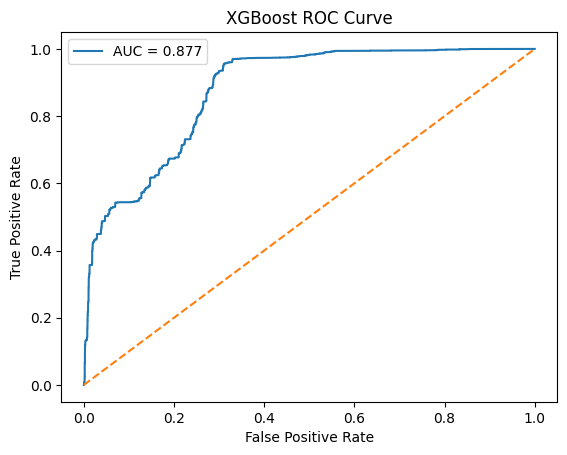

In [279]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_test_prob):.3f}")  
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

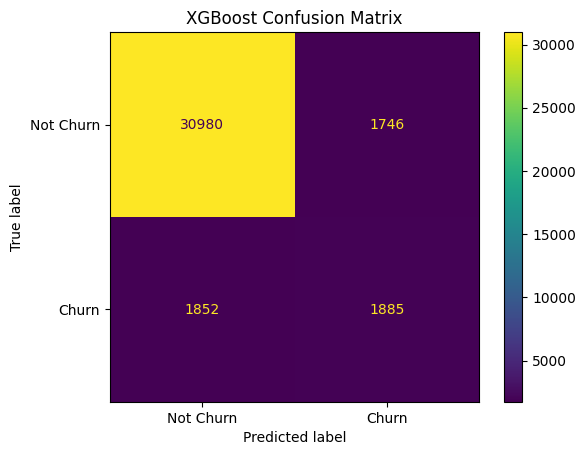

In [281]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test, y_test_pred)
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churn', 'Churn'])
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

##### 🔹 Random Forest Model (Baseline)

Random Forest is trained without hyperparameter tuning.

This serves as a baseline ensemble model.

Evaluation includes:
- Accuracy (Train & Test)
- Precision, Recall, F1-score
- AUC Score

Threshold is adjusted to improve churn detection.

In [282]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

# Train model (no tuning)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predict probabilities
y_train_prob_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Apply threshold
threshold = 0.2

y_train_pred_rf = (y_train_prob_rf > threshold).astype(int)
y_test_pred_rf = (y_test_prob_rf > threshold).astype(int)

#  Accuracy
print("=== Random Forest ===")

print("\nTrain Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))

# Classification report
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_rf))

# AUC
auc_rf = roc_auc_score(y_test, y_test_prob_rf)
print("AUC Score:", auc_rf)

=== Random Forest ===

Train Accuracy: 0.9685520824212708
Test Accuracy: 0.8994871513589118

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     32726
           1       0.54      0.14      0.22      3737

    accuracy                           0.90     36463
   macro avg       0.72      0.56      0.58     36463
weighted avg       0.87      0.90      0.87     36463

AUC Score: 0.7045753396757806


Threshold Tuning

In [283]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

# Train model (no tuning)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predict probabilities
y_train_prob_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# tuning threshold
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    
    y_pred_rf = (y_test_prob_rf > t).astype(int)

    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_rf))

#  Accuracy
print("=== Random Forest ===")

print("\nTrain Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))

# Classification report
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_rf))

# AUC
auc_rf = roc_auc_score(y_test, y_test_prob_rf)
print("AUC Score:", auc_rf)


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      1.00      0.94     32726
           1       0.00      0.00      0.00      3737

    accuracy                           0.89     36463
   macro avg       0.45      0.50      0.47     36463
weighted avg       0.81      0.89      0.85     36463


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.99      0.95     32726
           1       0.44      0.04      0.08      3737

    accuracy                           0.90     36463
   macro avg       0.67      0.52      0.51     36463
weighted avg       0.85      0.90      0.86     36463


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.90      0.99      0.95     32726
           1       0.49      0.09      0.15      3737

    accuracy                           0.90     36463
   macro avg       0.70      0.54      0.55     36463
weighted avg       0.86   